Adaptation from Horváth (2014) and T_stationary function from $\texttt{ftsa}$ R package.

In [ ]:
# R function
T_stationary <- function(sample, L = 49, J = 500, MC_rep=1000, cumulative_var = .90, Ker1 = FALSE, Ker2 = TRUE, h = ncol(sample)^.5, pivotal=FALSE, use_table = FALSE, significance = c("10%", "5%", "1%")){
  xrefine = N = ncol(sample)
  trefine = nrow(sample)
  if(Ker1)
  {
    K=function(x)
    {
      output = min(1, max(1.1-abs(x),0))
      return(output)
    }
  }
  if(Ker2)
  {
    K=function(x)
    {
      output = min(1, max(2-2*abs(x),0))
      return(output)
    }
  }
  
  
  basis = create.fourier.basis(c(0,1),L)
  ld = length(cumulative_var)
  h1 = h
  
  if(use_table & (ld == 1)){
    possible_levels = c("10%", "5%", "1%")
    match.arg(significance, possible_levels)
    significance = match(significance, possible_levels)
    text_level = possible_levels[significance]
    
    critical_values = generate_critical_values()
  } else if(ld > 1){
    stop("Table procedure is only available for one cumulative variance value")
  }
  
  
  
  X1_bar = rowMeans(sample)
  mean_subtracted_X1 = sample - X1_bar
  gamma_hat = lapply(0:(N-1), gamma_matrix, process = mean_subtracted_X1)
  cov_sample1 = gamma_hat[[1]]
  for(index in 1:(N-1))
  {
    cov_sample1 = cov_sample1 + K(index/h1) *(gamma_hat[[index+1]] + t(gamma_hat[[index+1]]))
  }
  Z_matrix = cov_sample1
  
  e1 = list()
  for(index in 1:L)
  {
    e1[index] = list(as.matrix(eval.basis(evalarg =(1:trefine)/trefine, basisobj = basis,Lfdobj=0)[,index]))
  }
  eigenvalues1 = (eigen(Z_matrix)$values)/trefine
  D = matrix(0,L,L)
  for(k in 1:L)
  {
    for(ell in 1:L)
    {
      Integrand_matrix = Z_matrix * (e1[[k]] %*% t(e1[[ell]]))
      D[k,ell] = 1/(trefine^2)*sum(Integrand_matrix)
    }
  }
  eigenpairs = eigen(D)
  eigenvectors = eigenpairs$vec
  eigenvectors2 = eigen(Z_matrix)$vectors
  eigenvalues = eigenpairs$val
  evals = eigenvalues
  if(pivotal)
  {
    d = c(1:ld)
    switch = 0
    stoper = 1
    spot = 1
    while(switch==0)
    {
      while((sum(eigenvalues[c(1:spot)])/sum(eigenvalues)) < cumulative_var[stoper])
      {
        spot = spot+1
      }
      d[stoper] = spot
      stoper = stoper+1
      if(stoper == (length(d)+1))
      {
        switch = 1
      }
    }
    T_N0=1:ld
    for(r in 1:ld)
    {
      ds=d[r]
      inp.matrix=matrix(0,ds,N)
      eig.v.norm=((trefine)^.5)*eigenvectors2
      for(j in (1:ds))
      {
        for(k in (1:N))
        {
          inp.matrix[j,k]=t(sample[,k])%*%(eig.v.norm[,j])/trefine
        }
      }
      T_Nsum=rep(0,ds)
      for(j in (1:ds))
      {
        s.0=sum(inp.matrix[j,(1:xrefine)])
        for(x in (1:xrefine))
        {
          T_Nsum[j]=T_Nsum[j]+(1/xrefine)*((1/N^.5)*(sum(inp.matrix[j,(1:x)])-(x/xrefine)*s.0))^2
        }
      }
      T_N0[r]=sum(T_Nsum/eigenvalues[1:ds])
    }
    
    if(use_table){
      
      if(d>30){
        warning("The table only allows for 30 FPC, the conclusion might be wrong")
        d = 30
      }
      T_N0 = round(T_N0, 6)
      is_rejected = 1*(T_N0 > critical_values[significance, d])
      if(is_rejected){
        conclusion = 'Reject the null hypothesis\n'
      } else {
        conclusion = "Do not reject the null hypothesis\n"
      }
      
      cat("\n")
      cat("Pivotal test of stationarity for a functional time series\n")
      cat("\n")
      cat("null hypothesis: the series is stationary\n")
      cat("\n")
      
      cat(paste("Critical Value at ", text_level, " = ", critical_values[significance, d], sep=""),"\n")
      cat(paste('Test Statistic:', T_N0, '\n'))
      cat(paste("N (number of functions) = ", N, sep=""),"\n")
      cat(paste("Conclusion:", conclusion))
      
      cat("\n")
      
    } else {
      
      T = vector(, MC_rep)
      T_array = matrix(0, length(d), MC_rep)
      lambda = eigenvalues
      for(dd in 1:length(d))
      {
        for(k in 1:MC_rep)
        {
          z=rnorm(d[dd]*J)
          tot=0
          for(n in c(1:d[dd]))
          {
            sum1 = 0
            sum1 =sum((z[c(((n-1)*d[dd]+1):((n-1)*d[dd]+J))]/(pi*c(1:J)))^2)
            tot = tot+sum1
          }
          T_array[dd,k] = T[k] = tot
        }
      }
      p_values=(1:ld)
      for(dd in 1:length(d))
      {
        p_values[dd] = round(1 - ecdf(T_array[dd,])(T_N0[dd]),4)
      }
      cat("\n")
      cat("Pivotal test of stationarity for a functional time series\n")
      cat("\n")
      cat("null hypothesis: the series is stationary\n")
      cat("\n")
      
      cat(paste("p-value = ", p_values, sep=""),"\n")
      cat(paste("N (number of functions) = ", N, sep=""),"\n")
      cat(paste("number of MC replications = ", MC_rep, sep=""))
      cat("\n")
    }
  } else {
    T = vector(, MC_rep)
    T_array = (1: MC_rep)
    lambda = eigenvalues
    d = min(c(length(which(lambda>0)),15))
    for(k in 1:MC_rep)
    {
      z=rnorm(d*J)
      tot=0
      for(n in c(1:d))
      {
        sum1 = 0
        sum1 =sum((z[c(((n-1)*d+1):((n-1)*d+J))]/(pi*c(1:J)))^2)
        tot = tot+lambda[n]*sum1
      }
      T_array[k] = T[k] = tot
    }
    int = sum(((1/sqrt(N)) *((sample[,1])-(1/xrefine)*rowSums(sample)))^2/(xrefine * trefine))
    for(x in 2:xrefine)
    {
      int = int + sum(((1/sqrt(N)) * (rowSums(sample[,1:x]) -(x/xrefine) * rowSums(sample)))^2/(xrefine * trefine))
    }
    statT_N = int
    p_values=(1:ld)
    for(dd in 1:length(d))
    {
      p_values = round(1 - ecdf(T_array)(statT_N),4)
    }
    cat("\n")
    cat("Monte Carlo test of stationarity of a functional time series\n")
    cat("\n")
    cat("null hypothesis: the series is stationary\n")
    cat("\n")
    
    cat(paste("p-value = ", p_values, sep=""),"\n")
    cat(paste("N (number of functions) = ", N, sep=""),"\n")
    cat(paste("number of MC replications = ", MC_rep, sep=""))
    cat("\n")
  }
}



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from typing import Dict, Optional, Union, List

In [26]:
class FunctionalStationarityTest:
    """
    Implements the Horváth, Kokoszka, and Rice (2014) test for stationarity 
    in functional time series.

    This class provides tools to test whether a sequence of density functions 
    (or any functional data) is stationary or contains a structural break. 
    It uses a pivotal CUSUM-based approach and functional principal component 
    analysis (FPCA) for dimension reduction.

    Attributes:
        sample (np.ndarray): The J x N data matrix.
        J (int): Number of grid points (discretization level).
        N (int): Number of functional observations (time points).
        grid_vals (np.ndarray): The spatial grid for the functional data.
        cumulative_var (float): Variance threshold for choosing the number of FPCs.
        results (Dict): Results from the run_test method.
    """

    def __init__(
        self, 
        sample: Union[np.ndarray, pd.DataFrame], 
        grid_vals: Optional[np.ndarray] = None, 
        cumulative_var: float = 0.90
    ) -> None:
        """
        Initializes the test with functional data.

        Args:
            sample: A J x N matrix where columns are functions and rows are grid points.
            grid_vals: The x-axis values for the functions. Defaults to [0, 1].
            cumulative_var: Fraction of variance (0.0 to 1.0) to retain in FPCA.
        """
        self.sample: np.ndarray = np.asarray(sample)
        self.J, self.N = self.sample.shape
        self.grid_vals: np.ndarray = (
            grid_vals if grid_vals is not None else np.linspace(0, 1, self.J)
        )
        self.cumulative_var: float = cumulative_var
        
        self.results: Dict[str, Union[float, int]] = {}
        self.mean_density: np.ndarray = np.mean(self.sample, axis=1, keepdims=True)
        self.centered_data: np.ndarray = self.sample - self.mean_density

    def _get_kernel_weight(self, x: float, kernel_type: int = 2) -> float:
        """Computes Bartlett-type kernel weights for long-run covariance."""
        if kernel_type == 1:
            return float(np.maximum(0, np.minimum(1, 1.1 - np.abs(x))))
        return float(np.maximum(0, np.minimum(1, 2 - 2 * np.abs(x))))

    def run_test(
        self, 
        mc_rep: int = 1000, 
        kernel_type: int = 2, 
        h: Optional[float] = None
    ) -> Dict[str, Union[float, int]]:
        """
        Executes the pivotal stationarity test using Monte Carlo simulation.

        Args:
            mc_rep: Number of Monte Carlo replications for p-value estimation.
            kernel_type: 1 for Ker1, 2 for Ker2 (default).
            h: Bandwidth for long-run covariance. Defaults to sqrt(N).

        Returns:
            A dictionary containing the p-value, test statistic, 
            number of components used (d), and estimated break point (k_star).
        """
        N, J = self.N, self.J
        h_val: float = h if h is not None else N**0.5
        X: np.ndarray = self.centered_data

        # 1. Estimate Long-Run Covariance Matrix (Z)
        Z: np.ndarray = (X @ X.T) / N
        for lag in range(1, int(h_val) + 1):
            weight = self._get_kernel_weight(lag / h_val, kernel_type)
            if weight > 0:
                gamma_lag = (X[:, lag:] @ X[:, :-lag].T) / N
                Z += weight * (gamma_lag + gamma_lag.T)

        # 2. Eigen-decomposition (Standardized by grid resolution)
        eigenvalues, eigenvectors = np.linalg.eigh(Z)
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[idx] / J
        eigenvectors = eigenvectors[:, idx] * np.sqrt(J)

        # 3. Determine 'd' (Dimension Reduction)
        exp_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
        d: int = int(np.searchsorted(exp_var, self.cumulative_var) + 1)
        
        # 4. Compute Test Statistic
        scores = (X.T @ eigenvectors[:, :d]).T / J
        cusum_process = np.cumsum(scores, axis=1)
        bridge = (1/np.sqrt(N)) * (
            cusum_process - (np.arange(1, N+1)/N) * cusum_process[:, -1:]
        )
        stat: float = float(np.sum(np.mean(bridge**2, axis=1) / eigenvalues[:d]))

        # 5. Monte Carlo Simulation for Null Distribution
        k_grid = np.arange(1, 101)
        z = np.random.normal(0, 1, (mc_rep, d, 100))
        simulated_stats = np.sum(
            np.sum(z**2 / (np.pi**2 * k_grid**2), axis=2), axis=1
        )
        p_val: float = float(np.mean(simulated_stats > stat))

        # Estimate Break Point (k*)
        norms = np.linalg.norm(np.cumsum(X, axis=1), axis=0)
        k_star: int = int(np.argmax(norms))

        self.results = {
            "p_value": p_val, 
            "statistic": stat, 
            "d": d, 
            "k_star": k_star
        }
        return self.results
    
    def analyze_persistence(self) -> Dict[str, Union[float, str]]:
        """
        Analyzes the persistence and volatility of the functional CUSUM trajectory.
        
        Metrics Explained:
        ------------------
        - persistence_ratio: Ratio of the final cumulative deviation to the maximum 
        deviation. 
        * Values > 0.5: Suggest a permanent structural break (the shift 'stuck').
        * Values < 0.5: Suggest a temporary shock (the density eventually reverted).
        
        - crossing_rate: Frequency at which the CUSUM norm crosses its own mean.
        * High Rate: Indicates 'wiggling' or high-frequency volatility.
        * Low Rate: Indicates a smooth 'drift' toward a new regime.
        
        - k_star: The time index (day) of the maximum cumulative deviation. 
        Represents the likely location of a structural regime shift.
        """
        raw_cusum = np.cumsum(self.centered_data, axis=1)
        norms = np.linalg.norm(raw_cusum, axis=0)
        
        k_star = int(np.argmax(norms))
        max_dev = np.max(norms)
        persistence_ratio = norms[-1] / max_dev if max_dev > 0 else 0
        
        crossings = len(np.where(np.diff(np.sign(norms - np.mean(norms))))[0])
        crossing_rate = crossings / self.N
        
        # Interpretation logic
        if persistence_ratio > 0.5 and crossing_rate < 0.2:
            interpretation = "Permanent Structural Break"
        else:
            interpretation = "Temporary Volatility Shock / Mean Reversion"

        persistence_results = {
            "k_star": k_star,
            "persistence_ratio": float(persistence_ratio),
            "crossing_rate": float(crossing_rate),
            "interpretation": interpretation
        }
        self.results.update(persistence_results)
        return persistence_results

    def plot_cusum(self, n_lines: int = 10) -> None:
        """
        Visualizes the Functional CUSUM process to diagnose structural instability.

        The plot renders snapshots of the Brownian Bridge-like process over time. 
        Each curve represents the accumulated discrepancy between the densities 
        up to that day and the global mean density of the entire period.

        Interpretation:
        ---------------------------------------
        1. Curve Amplitude: High peaks or deep valleys indicate regions of the 
           return grid where the local distribution significantly deviates from 
           the 250-day average (e.g., higher peaks = lower local volatility).
           
        2. Temporal Convergence: 
           - If the final curves (darker colors) remain far from the zero-axis, 
             it visually confirms a 'Permanent Structural Break'.
           - If the curves 'bloom' outward and then collapse back toward zero, 
             it indicates a 'Temporary Volatility Shock'.
             
        3. Shape of the Bridge: A consistent 'bulge' in the center suggests 
           changes in the mean or variance, while 'wiggles' in the far ends 
           suggest instability in the tail-risk (heavy tails).

        Args:
            n_lines (int): Number of snapshots to plot across the time horizon.
        """
        if not self.results:
            print("Warning: Run .run_test() first for an accurate plot title.")
            
        bridge = (1 / np.sqrt(self.N)) * np.cumsum(self.centered_data, axis=1)
        plot_indices = np.linspace(0, self.N - 1, n_lines, dtype=int)

        plt.figure(figsize=(10, 6))
        colors = sns.color_palette("rocket", n_lines)
        
        for i, day in enumerate(plot_indices):
            plt.plot(self.grid_vals, bridge[:, day], color=colors[i], 
                     label=f"Day {day}", alpha=0.7)
            
        plt.axhline(0, color='black', lw=1, ls='--')
        p_val_str = f"{self.results.get('p_value', 'N/A')}"
        plt.title(f"Functional CUSUM (p-value: {p_val_str})")
        plt.xlabel("Grid (e.g., Financial Returns)")
        plt.ylabel("Cumulative Deviation")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Time Step")
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

    def get_summary(self) -> str:
        """
        Returns a formatted summary string of the test results.
        """
        res = self.results
        if not res:
            return "No results found. Please call .run_test() first."
            
        status = "REJECTED" if res['p_value'] < 0.05 else "NOT REJECTED"
        print (
            f"--- Functional Stationarity Analysis ---\n"
            f"Null Hypothesis (H0): Series is stationary\n"
            f"Result: {status} (p = {res['p_value']:.4f})\n"
            f"Components (d): {res['d']} FPCs\n"
            f"Detected Break (k*): Day {res['k_star']}\n"
            f"----------------------------------------"
        )

In [27]:
def generate_test_densities(n_days=250, n_grid=5001, scenario="stationary"):
    grid = np.linspace(-5, 5, n_grid)
    densities = np.zeros((n_grid, n_days))
    
    np.random.seed(42)
    
    if scenario == "stationary":
        # Mean and Vol remain constant, only small random noise
        for t in range(n_days):
            mu = 0 + np.random.normal(0, 0.02)
            sigma = 1 + np.random.normal(0, 0.02)
            densities[:, t] = norm.pdf(grid, mu, sigma)
            
    elif scenario == "break":
        # A structural break occurs at Day 125 (k*)
        # Shift from low volatility to high volatility
        for t in range(n_days):
            if t < 125:
                mu, sigma = 0, 1.0
            else:
                mu, sigma = 0, 1.5 # Volatility jump
            
            # Add a tiny bit of noise so it's not a perfect step function
            mu += np.random.normal(0, 0.01)
            sigma += np.random.normal(0, 0.01)
            densities[:, t] = norm.pdf(grid, mu, sigma)
            
    return pd.DataFrame(densities), grid

# Generate both datasets
df_stat, grid = generate_test_densities(scenario="stationary")
df_break, _ = generate_test_densities(scenario="break")

# Save to CSV to import into R for comparison
# df_stat.to_csv("stationary_test.csv", index=False)
# df_break.to_csv("break_test.csv", index=False)

<Axes: title={'center': 'Stationary FTS'}>

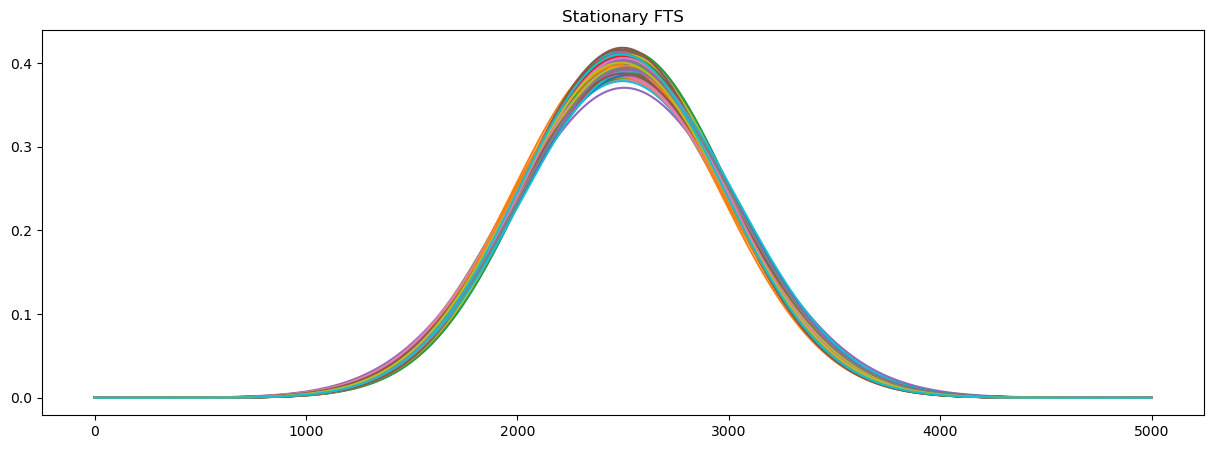

In [31]:
df_stat.plot(figsize=(15,5), legend=False, title="Stationary FTS")

In [29]:
# 1. Initialize the class with your 5001x250 density matrix
tester = FunctionalStationarityTest(df_stat, grid_vals=grid)

# 2. Run the math
tester.run_test(mc_rep=2000)

# 3. Print results for your paper
tester.get_summary()

--- Functional Stationarity Analysis ---
Null Hypothesis (H0): Series is stationary
Result: NOT REJECTED (p = 0.3065)
Components (d): 2 FPCs
Detected Break (k*): Day 131
----------------------------------------


In [30]:
tester.analyze_persistence()

{'k_star': 131,
 'persistence_ratio': 4.550309097782339e-13,
 'crossing_rate': 0.064,
 'interpretation': 'Temporary Volatility Shock / Mean Reversion'}

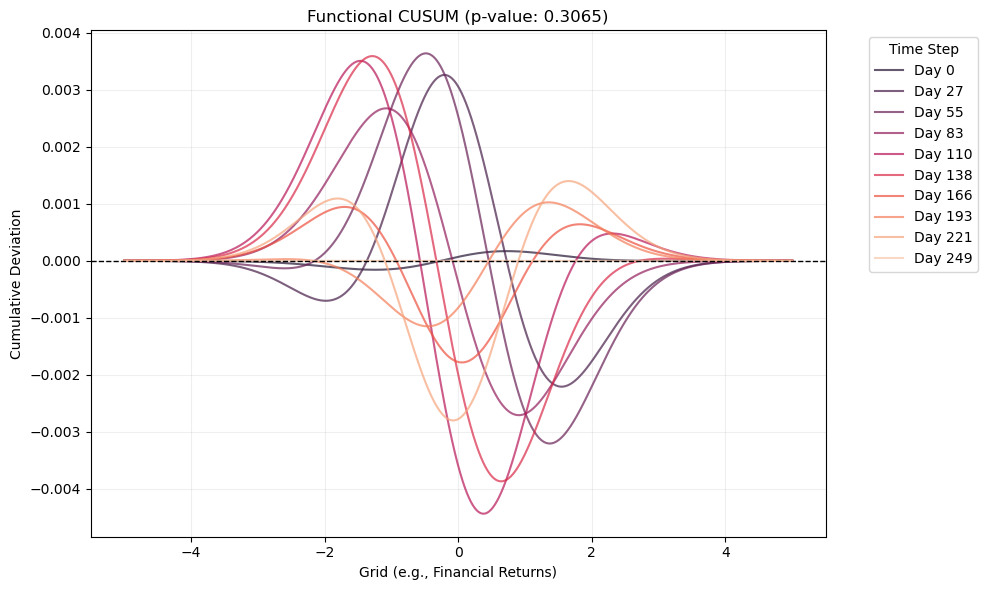

In [17]:
# 4. Generate the visualization
tester.plot_cusum()

<Axes: title={'center': 'Non-stationary FTS'}>

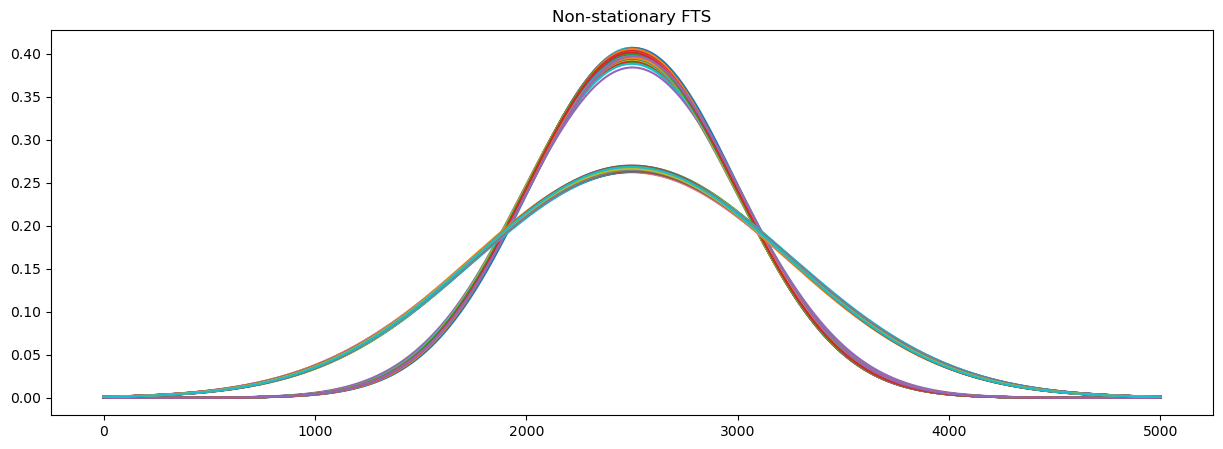

In [32]:
df_break.plot(figsize=(15,5), legend=False, title="Non-stationary FTS")

In [ ]:
# 1. Initialize the class with your 5001x250 density matrix
tester = FunctionalStationarityTest(df_break, grid_vals=grid)

# 2. Run the math
tester.run_test(mc_rep=2000)

# 3. Print results for your paper
tester.get_summary()

In [ ]:
tester.analyze_persistence()

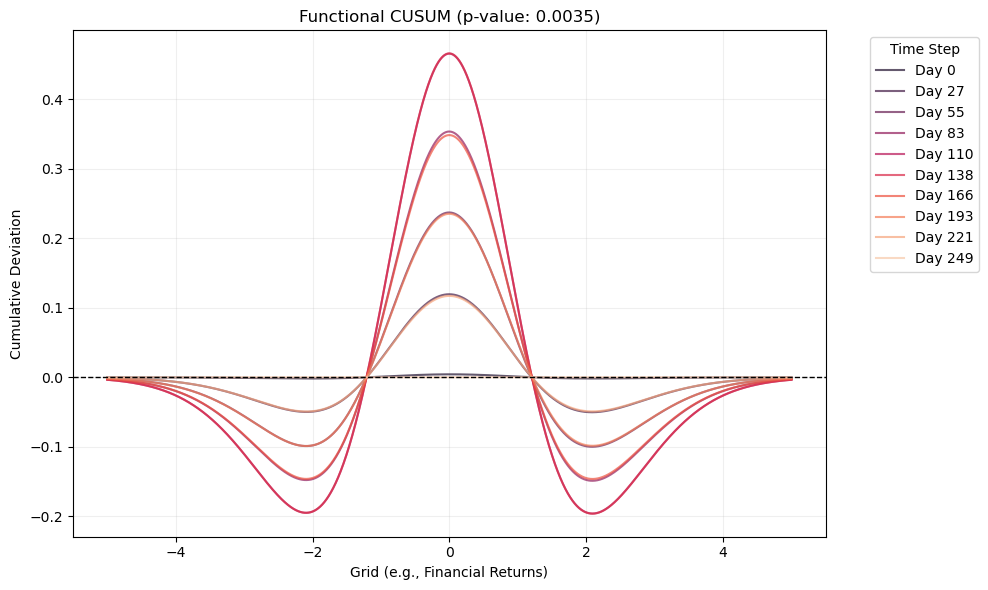

In [ ]:
# 4. Generate the visualization
tester.plot_cusum()